<a href="https://colab.research.google.com/github/AliefReefandi/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 — Classification

## 1. Tujuan Pembelajaran

Pada chapter ini akan dipelajari konsep dasar **classification**, yaitu metode untuk memprediksi suatu data ke dalam kategori atau kelas tertentu.

Setelah menyelesaikan chapter ini, diharapkan dapat:

- Memahami konsep classification.
- Memahami Naive Bayes.
- Memahami Discriminant Analysis dan Linear Discriminant Analysis (LDA).
- Memahami Logistic Regression.
- Memahami cara mengevaluasi model classification.
- Memahami confusion matrix, accuracy, precision, recall, dan specificity.
- Memahami ROC Curve dan AUC.
- Memahami masalah imbalanced data.
- Memahami teknik undersampling dan oversampling.

## 2. Ringkasan Chapter

Classification merupakan proses memprediksi suatu record ke dalam satu atau lebih kategori.

Contoh classification:

- Apakah sebuah loan akan default atau tidak?
- Apakah transaksi termasuk fraud atau bukan?
- Apakah pelanggan akan melakukan pembelian?
- Apakah sebuah email termasuk spam atau bukan?

Dalam classification biasanya terdapat **class of interest**, yaitu kelas yang menjadi perhatian utama. Pada binary classification, kelas tersebut biasanya diberi nilai **1**, sedangkan kelas lainnya diberi nilai **0**.

Chapter ini membahas beberapa metode classification:

1. Naive Bayes
2. Discriminant Analysis
3. Logistic Regression

Selain membuat model, chapter ini juga membahas bagaimana mengevaluasi hasil classification menggunakan berbagai metrik seperti accuracy, confusion matrix, precision, recall, specificity, ROC curve, AUC, dan lift.

Chapter kemudian membahas masalah **imbalanced data**, yaitu kondisi ketika salah satu kelas jauh lebih sedikit dibandingkan kelas lainnya.

## 3. Konsep Teoritis

## 3.1 Classification

Classification adalah proses memprediksi kategori atau kelas dari suatu record berdasarkan predictor variables.

Pada binary classification hanya terdapat dua kelas, misalnya:

- 0 = tidak default
- 1 = default

Model classification biasanya tidak hanya menghasilkan kelas, tetapi juga dapat menghasilkan **probability** atau probabilitas suatu record termasuk ke dalam class of interest.

Secara umum proses classification:

1. Membuat model menggunakan data training.
2. Mengestimasi probabilitas sebuah record termasuk class of interest.
3. Membandingkan probabilitas tersebut dengan cutoff.
4. Menentukan kelas berdasarkan cutoff.

Contohnya, jika cutoff = 0.5:

- probability > 0.5 → class 1
- probability ≤ 0.5 → class 0

## 3.2 Naive Bayes

Naive Bayes merupakan metode classification yang menggunakan probabilitas predictor terhadap suatu outcome.

Ide dasarnya adalah menghitung:

P(Y | X)

yaitu probabilitas suatu outcome Y berdasarkan predictor X.

Naive Bayes menggunakan asumsi bahwa predictor variables bersifat **conditionally independent** ketika outcome sudah diketahui.

Secara sederhana:

1. Hitung probabilitas setiap kelas.
2. Hitung probabilitas predictor untuk masing-masing kelas.
3. Gabungkan probabilitas tersebut.
4. Pilih kelas dengan probabilitas terbesar.

Metode ini disebut "naive" karena menggunakan asumsi sederhana bahwa predictor variables bersifat independen satu sama lain berdasarkan kelas.

Naive Bayes sangat berguna terutama ketika terdapat banyak predictor dan proses classification perlu dilakukan dengan cepat.

In [1]:
#Contoh Naive

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Contoh data sederhana
data = pd.DataFrame({
    'Income': [30, 35, 40, 45, 50, 55, 60, 65],
    'CreditScore': [500, 520, 540, 560, 580, 600, 620, 640],
    'Default': [1, 1, 1, 0, 0, 0, 0, 0]
})

X = data[['Income', 'CreditScore']]
y = data['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Prediksi:", pred)
print("Accuracy:", accuracy_score(y_test, pred))

Prediksi: [1 0]
Accuracy: 1.0


## 3.3 Discriminant Analysis

Discriminant Analysis merupakan metode classification yang menggunakan hubungan antar predictor variables untuk membedakan beberapa kelas.

Salah satu metode yang dibahas dalam buku adalah:

**Linear Discriminant Analysis (LDA)**

LDA menggunakan covariance matrix dan discriminant function untuk memisahkan data berdasarkan kelas.

Konsep penting:

- **Covariance** → mengukur bagaimana dua variabel berubah secara bersamaan.
- **Covariance Matrix** → kumpulan covariance dan variance dari predictor variables.
- **Discriminant Function** → fungsi yang digunakan untuk memisahkan kelas.
- **Discriminant Weights** → skor yang digunakan untuk menentukan kemungkinan sebuah record masuk ke kelas tertentu.

LDA pada dasarnya mencari garis atau fungsi yang dapat memisahkan data dari kelas yang berbeda.

LDA dapat digunakan dengan lebih dari dua predictor variables selama jumlah data cukup untuk mengestimasi covariance matrix.

In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = data[['Income', 'CreditScore']]
y = data['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

pred = lda.predict(X_test)

print("Prediksi:", pred)
print("Accuracy:", accuracy_score(y_test, pred))

Prediksi: [1 0]
Accuracy: 1.0


## 3.4 Logistic Regression

Logistic Regression mirip dengan Linear Regression, tetapi digunakan ketika outcome yang diprediksi bersifat binary.

Contohnya:

- 0 = tidak default
- 1 = default

Logistic Regression menghasilkan probabilitas antara 0 dan 1.

Model menggunakan **logit** atau **log odds** untuk menghubungkan predictor variables dengan probabilitas.

Fungsi logistic:

p = 1 / (1 + e^(-z))

dengan:

z = β0 + β1X1 + β2X2 + ... + βqXq

Fungsi tersebut memastikan nilai probabilitas berada antara 0 dan 1.

Logistic Regression menggunakan **Maximum Likelihood Estimation (MLE)** untuk mendapatkan parameter model.

Berbeda dengan Linear Regression, Logistic Regression tidak menggunakan RMSE dan R-squared sebagai metrik utama evaluasi.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = data[['Income', 'CreditScore']]
y = data['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

logit = LogisticRegression()
logit.fit(X_train, y_train)

pred = logit.predict(X_test)
prob = logit.predict_proba(X_test)[:, 1]

print("Prediksi:", pred)
print("Probability class 1:", prob)
print("Accuracy:", accuracy_score(y_test, pred))

Prediksi: [1 0]
Probability class 1: [9.99993144e-01 2.47305862e-09]
Accuracy: 1.0


## 3.5 Evaluating Classification Models

Setelah model classification dibuat, model perlu dievaluasi.

Beberapa metrik yang digunakan dalam classification:

- Accuracy
- Confusion Matrix
- Sensitivity / Recall
- Specificity
- Precision
- ROC Curve
- AUC
- Lift

Tidak cukup hanya menggunakan accuracy karena pada data yang tidak seimbang, accuracy dapat memberikan gambaran yang menyesatkan.

Oleh karena itu, beberapa metrik perlu digunakan secara bersamaan untuk memahami performa model.

## 3.6 Confusion Matrix

Confusion Matrix merupakan tabel yang menunjukkan jumlah prediksi benar dan salah berdasarkan kelas aktual dan kelas hasil prediksi.

Pada binary classification terdapat empat kemungkinan:

- True Positive (TP) → aktual 1 dan diprediksi 1
- True Negative (TN) → aktual 0 dan diprediksi 0
- False Positive (FP) → aktual 0 tetapi diprediksi 1
- False Negative (FN) → aktual 1 tetapi diprediksi 0

Confusion matrix menjadi dasar untuk menghitung berbagai metrik classification.

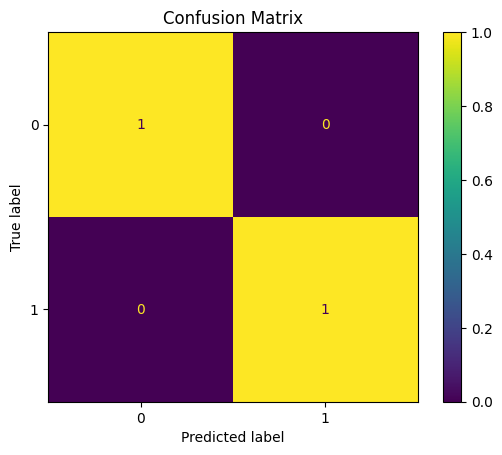

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred)

plt.title("Confusion Matrix")
plt.show()

## 3.7 Accuracy, Precision, Recall, dan Specificity

### Accuracy

Accuracy menunjukkan proporsi seluruh prediksi yang benar.

Accuracy = (TP + TN) / Total Data

### Precision

Precision menunjukkan seberapa banyak prediksi class 1 yang benar-benar merupakan class 1.

Precision = TP / (TP + FP)

### Recall / Sensitivity

Recall menunjukkan kemampuan model menemukan class 1 yang sebenarnya.

Recall = TP / (TP + FN)

### Specificity

Specificity menunjukkan kemampuan model mengenali class 0.

Specificity = TN / (TN + FP)

Pemilihan metrik bergantung pada tujuan classification. Misalnya, jika class 1 sangat penting untuk ditemukan, recall dapat menjadi metrik yang penting untuk diperhatikan.

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, zero_division=0)
recall = recall_score(y_test, pred, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

specificity = tn / (tn + fp)

print("Accuracy    :", accuracy)
print("Precision   :", precision)
print("Recall      :", recall)
print("Specificity :", specificity)

Accuracy    : 1.0
Precision   : 1.0
Recall      : 1.0
Specificity : 1.0


## 3.8 ROC Curve dan AUC

ROC Curve digunakan untuk melihat performa classification model pada berbagai probability cutoff.

ROC membandingkan:

- True Positive Rate / Sensitivity
- False Positive Rate

Dengan mengubah cutoff, jumlah data yang diklasifikasikan sebagai class 1 juga berubah.

**AUC (Area Under the Curve)** merupakan luas area di bawah ROC curve.

AUC digunakan untuk mengukur kemampuan model dalam membedakan class 1 dan class 0.

Semakin besar kemampuan model membedakan kedua kelas, semakin besar nilai AUC.

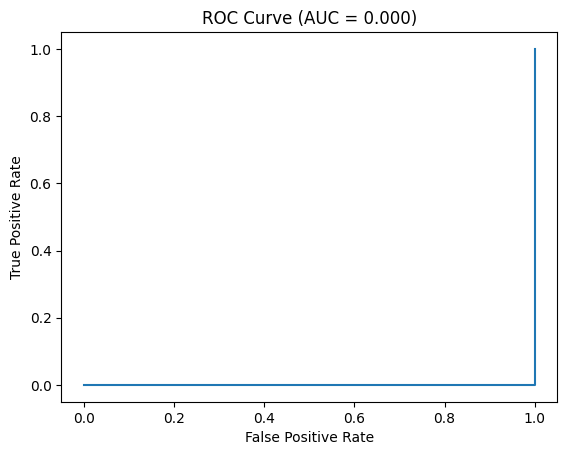

AUC: 0.0


In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, prob)

auc = roc_auc_score(y_test, prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.show()

print("AUC:", auc)

## 3.9 Imbalanced Data

Imbalanced data adalah kondisi ketika jumlah data antar kelas tidak seimbang.

Contoh:

- Class 0 = 95%
- Class 1 = 5%

Jika model selalu memprediksi class 0, accuracy dapat terlihat tinggi meskipun model gagal menemukan class 1.

Masalah ini sering terjadi ketika class of interest merupakan kejadian yang relatif jarang, seperti:

- Fraud
- Loan default
- Penyakit tertentu
- Transaksi mencurigakan

Karena itu, evaluasi tidak cukup menggunakan accuracy saja.

Metrik seperti precision, recall, specificity, dan AUC dapat memberikan informasi yang lebih lengkap.

## 3.10 Strategi Mengatasi Imbalanced Data

Beberapa strategi yang dibahas dalam buku adalah:

### 1. Undersampling

Mengurangi jumlah record dari kelas yang jumlahnya lebih banyak.

Contoh:

Class 0 = 90.000 data
Class 1 = 10.000 data

Sebagian data Class 0 dapat dikurangi sehingga jumlah kedua kelas menjadi lebih seimbang.

### 2. Oversampling

Menambah jumlah record dari kelas yang lebih sedikit.

Oversampling dapat dilakukan dengan melakukan sampling ulang terhadap class yang jarang.

### 3. Up/Down Weighting

Memberikan bobot berbeda pada masing-masing kelas sehingga class yang jarang mendapatkan bobot lebih besar.

### 4. Data Generation

Membuat data sintetis berdasarkan data yang sudah tersedia.

Salah satu teknik yang dibahas adalah SMOTE.

### 5. Cost-Based Classification

Mempertimbangkan biaya atau konsekuensi dari kesalahan classification.

Misalnya, kesalahan tidak mendeteksi loan default dapat memiliki biaya yang berbeda dengan kesalahan memprediksi loan yang sebenarnya tidak default sebagai default.

# 4. Summary dan Kesimpulan

## Summary

Chapter 5 membahas **Classification**, yaitu proses memprediksi sebuah record ke dalam kategori tertentu.

Beberapa metode classification yang dibahas adalah:

- **Naive Bayes**, menggunakan probabilitas dan asumsi conditional independence.
- **Discriminant Analysis**, menggunakan covariance dan discriminant function untuk memisahkan kelas.
- **Logistic Regression**, menggunakan model berbasis log odds untuk menghasilkan probabilitas class.

Setelah model dibuat, performanya dapat dievaluasi menggunakan:

- Accuracy
- Confusion Matrix
- Precision
- Recall / Sensitivity
- Specificity
- ROC Curve
- AUC
- Lift

Chapter ini juga membahas **imbalanced data**, yaitu kondisi ketika jumlah data antar kelas tidak seimbang. Beberapa strategi yang dapat digunakan adalah undersampling, oversampling, weighting, data generation, dan cost-based classification.

## Kesimpulan

Classification digunakan ketika tujuan analisis adalah menentukan kategori atau kelas dari suatu record.

Pemilihan metode dan metrik evaluasi harus disesuaikan dengan karakteristik data dan tujuan permasalahan. Pada data yang tidak seimbang, penggunaan accuracy saja tidak cukup sehingga metrik lain seperti precision, recall, specificity, dan AUC perlu dipertimbangkan.

Dengan memahami classification, proses analisis dapat dilanjutkan dari sekadar melakukan prediksi menjadi mengevaluasi seberapa baik model membedakan kelas yang menjadi tujuan analisis.